In [1]:
import numpy as np 
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import train_test_split


In [2]:
df =  pd.read_csv(r"C:\Users\Ameet Computer\OneDrive\Pictures\Camera Roll\salary regression data\Salary Data.csv")
df.head(5)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
df.shape

(375, 6)

In [5]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
370     True
371    False
372     True
373     True
374     True
Length: 375, dtype: bool

In [3]:
df.duplicated().sum()

np.int64(50)

In [4]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
348    False
349    False
350    False
351    False
371    False
Length: 325, dtype: bool

I identified a small number of exact duplicate records and removed them to reduce redundancy and prevent overrepresentation of certain salary profiles in the training data. Because the dataset did not include a unique employee identifier, it was not possible to distinguish between repeated entries and different individuals with identical attributes

In [5]:
x = df.drop("Salary", axis=1)
y = df["Salary"]


In [15]:
# Check missing values
df.isnull().sum()

# Fill numerical columns
num_cols = ['Age', 'Years of Experience', 'Salary']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns
cat_cols = ['Gender', 'Education Level', 'Job Title']

for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

In [13]:
x

,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,Male,Bachelor's,Software Engineer,5.0
1,28.0,Female,Master's,Data Analyst,3.0
2,45.0,Male,PhD,Senior Manager,15.0
3,36.0,Female,Bachelor's,Sales Associate,7.0
4,52.0,Male,Master's,Director,20.0
...,...,...,...,...,...
348,28.0,Female,Bachelor's,Junior Operations Manager,1.0
349,36.0,Male,Bachelor's,Senior Business Development Manager,8.0
350,44.0,Female,PhD,Senior Data Scientist,16.0
351,31.0,Male,Bachelor's,Junior Marketing Coordinator,3.0


In [14]:
y

0       90000.0
1       65000.0
2      150000.0
3       60000.0
4      200000.0
         ...   
348     35000.0
349    110000.0
350    160000.0
351     55000.0
371    170000.0
Name: Salary, Length: 325, dtype: float64

"Machine learning algorithms work with numerical data, so I transformed categorical features such as gender, education level, and job title into numerical representations using one-hot encoding before training the model."

In [17]:
x_train,x_test,y_train,y_test = train_test_split(x,y, train_size= 0.2, random_state=42)


In [18]:
lin_reg = LinearRegression()
lin_reg.fit(x_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
x_train.isnull().sum()

Age                           0
Years of Experience           0
Gender_Male                   0
Education Level_Master's      0
Education Level_PhD           0
                             ..
Job Title_UX Designer         0
Job Title_UX Researcher       0
Job Title_VP of Finance       0
Job Title_VP of Operations    0
Job Title_Web Developer       0
Length: 178, dtype: int64

In [28]:
x_train = x_train.fillna(x_train.mean())
x_test = x_test.fillna(x_train.mean())

y_pred = lin_reg.predict(x_test)

In [29]:
y_pred

array([ 39000.        ,  61066.66666667, 165250.        , 106750.        ,
       135250.        , 123000.        ,  69566.66666667,  92250.        ,
       100066.66666667,   4816.66666667,  -6750.        ,  52066.66666667,
       164500.        ,  43316.66666667,  51566.66666667,  78816.66666667,
       188066.66666667, -41308.33333333,  78066.66666667,  65316.66666667,
        56816.66666667, 169750.        ,  91566.66666667, 101750.        ,
       229000.        , 152000.        ,  46625.        ,  40750.        ,
       236816.66666667, 131066.66666667, 186500.        ,  41250.        ,
       149500.        ,  82816.66666667, 170316.66666667, 104566.66666667,
       126566.66666667, 121316.66666667, 106500.        , 201566.66666667,
        44875.        ,  74066.66666667,  25500.        , 195250.        ,
        64816.66666667,  45875.        ,  60316.66666667,  60316.66666667,
       201816.66666667,  -4433.33333333,  74250.        , 153816.66666667,
        82816.66666667, 2

In [13]:
results = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Prediction Salary":y_pred
})

NameError: name 'y_pred' is not defined

In [31]:
results

,Actual Salary,Prediction Salary
0,45000.0,39000.000000
1,110000.0,61066.666667
2,170000.0,165250.000000
3,110000.0,106750.000000
4,170000.0,135250.000000
...,...,...
255,50000.0,72000.000000
256,80000.0,-35433.333333
257,180000.0,298000.000000
258,70000.0,63000.000000


In [37]:
mask = ~np.isnan(y_test) & ~np.isnan(y_pred)
y_test_clean = y_test[mask]
y_pred_clean = y_pred[mask]

r2 = r2_score(y_test_clean, y_pred_clean)
mae = mean_absolute_error(y_test_clean, y_pred_clean)
mse = mean_squared_error(y_test_clean, y_pred_clean)
rmse = np.sqrt(mse)

print("r2_score:", r2)
print("mae:", mae)
print("mse:", mse)
print("rmse:", rmse)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)


print("r2_score:", r2_score)
print("mae:", mae)

print("mse:", mse)

print("rmse:", rmse)

r2_score: -0.40891694305922366
mae: 44288.449163449346
mse: 3257874453.8288474
rmse: 57077.79300068326


ValueError: Input contains NaN.

In [38]:
dt_reg = DecisionTreeClassifier(random_state=42)
dt_reg.fit(x_train,y_train)
y_pred_dt = dt_reg.predict(x_test)

In [39]:
ridge_reg  = Ridge(alpha=1.0)
ridge_reg.fit(x_train,y_train)
y_pred_ridge =  ridge_reg.predict(x_test)


In [40]:
Lasso_reg  = Lasso(alpha=1.0)
Lasso_reg.fit(x_train,y_train)
y_pred_Lasso =  Lasso_reg.predict(x_test)


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.957e+08, tolerance: 1.641e+07
  model = cd_fast.enet_coordinate_descent(


In [44]:
def evaluate_model(name, y_true, y_pred):
    y_true_arr = y_true.to_numpy()
    mask = ~np.isnan(y_true_arr) & ~np.isnan(y_pred)
    y_true_c = y_true_arr[mask]
    y_pred_c = y_pred[mask]
    r2 = r2_score(y_true_c, y_pred_c)
    mae = mean_absolute_error(y_true_c, y_pred_c)
    mse = mean_squared_error(y_true_c, y_pred_c)
    rmse = np.sqrt(mse)
    print(f"{name} — r2: {r2:.4f}, MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}")
    return {"r2": r2, "mae": mae, "mse": mse, "rmse": rmse}

evaluate_model(
    "Ridge Regression",
    y_test, y_pred_ridge
)

evaluate_model(
    "Lasso Regression",
    y_test, y_pred_Lasso
)



Ridge Regression — r2: 0.9002, MAE: 11063.59, MSE: 230881010.93, RMSE: 15194.77
Lasso Regression — r2: 0.3156, MAE: 28842.28, MSE: 1582514033.28, RMSE: 39780.82


{'r2': 0.31561793871401367,
 'mae': 28842.283062123064,
 'mse': 1582514033.283665,
 'rmse': np.float64(39780.824944735185)}

Random Forest Algorthim

In [9]:
from sklearn.ensemble import RandomForestRegressor
x = df.drop("Salary", axis=1)
y = df["Salary"]

In [10]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size= 0.2, random_state=42)

In [12]:
######train 

rf_model = RandomForestRegressor(n_estimators=100, max_depth=5,random_state=42)
####n_estimator means how much u want to train trees

rf_model.fit(x_train,y_train)

ValueError: could not convert string to float: 'Unknown'

In [16]:
#### see columns which has unknown values or object etc 
for col in x_train.columns:
    if x_train[col].dtype == 'object':
        print(col, x_train[col].unique())

Gender ['Unknown' 'Male' 'Female']
Education Level ['Unknown' "Bachelor's" 'PhD' "Master's"]
Job Title ['Unknown' 'Junior Product Manager' 'Senior Engineer' 'Financial Manager'
 'Senior Training Specialist' 'Senior Business Analyst'
 'Director of Human Resources' 'Project Manager' 'Senior Project Manager'
 'Junior Business Analyst' 'Senior Human Resources Specialist'
 'Senior Marketing Analyst' 'Office Manager' 'Senior HR Generalist'
 'Customer Success Manager' 'Junior Business Operations Analyst'
 'Accountant' 'Junior Social Media Specialist' 'Senior Accountant'
 'Senior Marketing Manager' 'Senior Financial Manager'
 'Senior Product Manager' 'Product Manager' 'Junior Marketing Specialist'
 'Director of Operations' 'CEO' 'IT Support' 'Senior UX Designer'
 'Senior Data Engineer' 'UX Researcher' 'Junior Marketing Manager'
 'Senior IT Consultant' 'Data Analyst' 'Sales Executive'
 'Senior Data Scientist' 'Senior Project Coordinator'
 'Senior Product Designer' 'Senior Financial Analyst'
 'S

In [17]:
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

# Ensure both datasets have the same columns
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

In [18]:
######train 

rf_model = RandomForestRegressor(n_estimators=100, max_depth=5,random_state=42)
####n_estimator means how much u want to train trees

rf_model.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
y_pred = rf_model.predict(x_test)

In [20]:
y_pred

array([ 56435.14631603, 125366.71127914, 172802.02006951, 103923.09471387,
       203183.41836446, 172411.93711325,  49549.76611794, 100051.53841138,
        85610.51773611,  94461.8764178 , 102047.19677332, 142303.32593961,
       111767.79591126, 130632.17670807,  39917.85238054,  40108.32502268,
       142693.57908524,  44434.11796295,  49117.25362751,  40108.32502268,
        39842.85238054, 160640.00190426,  58214.42183668, 142469.42240941,
        84556.90792745, 172592.70634402,  39917.85238054,  49117.25362751,
       168860.41017635,  99163.12351696, 159342.33179897,  40451.02560167,
       172921.25083874,  50572.27588321, 146681.57883738,  85610.51773611,
        99163.12351696, 101232.20893346,  85610.51773611, 157692.4257908 ,
        39894.41488054,  49495.59945127, 100559.20019404, 130289.95198392,
        40183.32502268,  49486.72263968,  40133.32502268,  40133.32502268,
       150834.95827558,  91643.67781627,  90564.37369297, 101220.58170761,
        50572.27588321, 1

In [21]:
y_test

235     45000.0
110    110000.0
249    170000.0
9      110000.0
93     170000.0
         ...   
350    160000.0
233     85000.0
60     170000.0
124    140000.0
222    100000.0
Name: Salary, Length: 65, dtype: float64

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 8324.67880419643
MSE: 142886022.33978492
RMSE: 11953.494147728727
R2 Score: 0.9374093120459517


I developed a Random Forest Regression model and evaluated it using MAE, RMSE, and R² metrics. The model achieved an R² score of 0.937, meaning it explained approximately 94% of the variation in the target variable. The average prediction error was around 8.3k units, while the RMSE was approximately 12k units, indicating strong predictive performance."

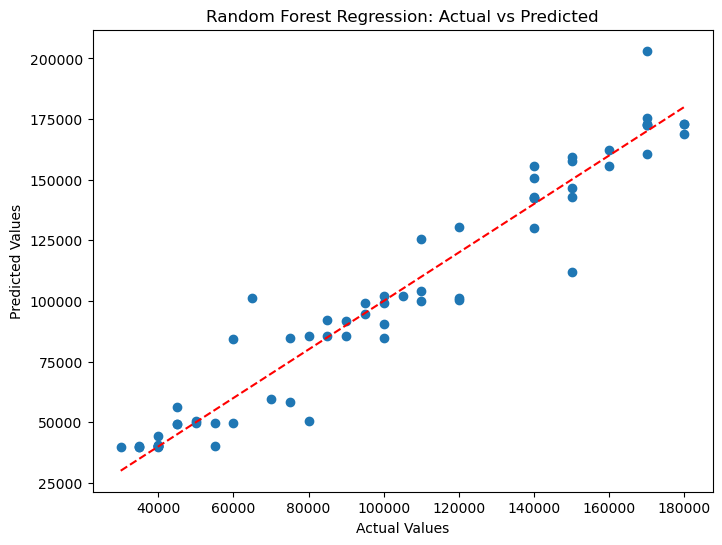

In [26]:
######Visualization 

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression: Actual vs Predicted")
plt.show()

Interpretation:
Points close to the red line = good predictions.
Points far from the line = larger errors.
If most points lie near the line, your model is performing well.

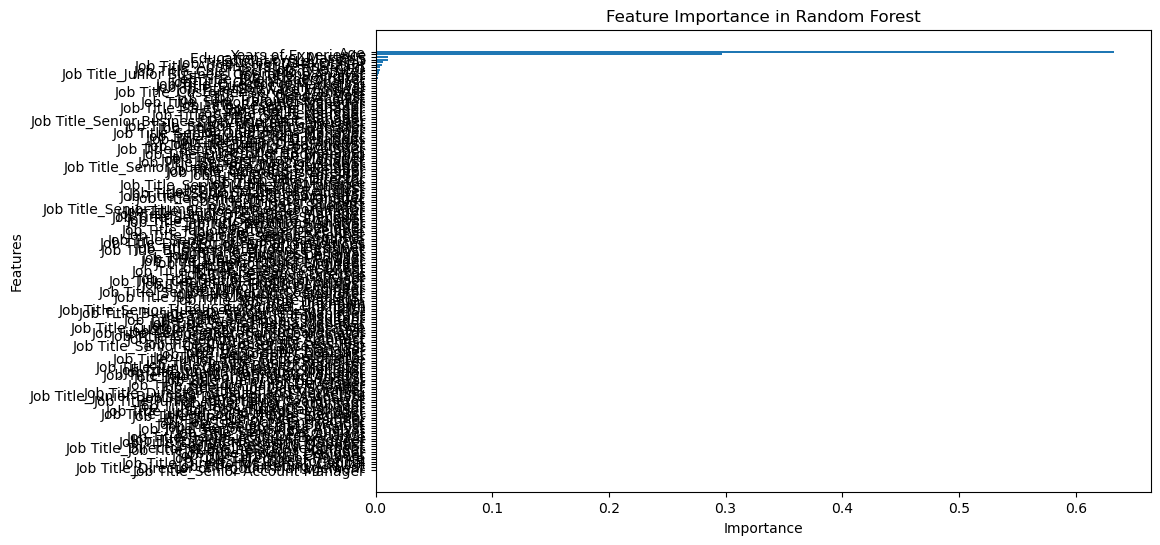

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance in Random Forest")
plt.gca().invert_yaxis()
plt.show()

Feature importance analysis showed that Years of Experience was the strongest predictor of salary, contributing approximately 63% of the model's decision-making process. Age was the second most influential feature with around 30% importance, while education level and specific job titles had comparatively smaller contributions. This indicates that salary in the dataset is driven primarily by experience and career progression.

AdaBoost Algorthim

In [28]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree  import DecisionTreeRegressor

In [29]:
x = df.drop('Salary', axis = 1)
y = ["Salary"]

In [31]:
x = df.drop('Salary', axis=1)
y = df['Salary']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [32]:
best_estimator =  DecisionTreeRegressor(max_depth=1) ### MAX_DEPTH ONE MEANS K STUMP WEIGHT KRNA SPLITTING TO ONLY TWO NODES

In [34]:
ada_model = AdaBoostRegressor(estimator=best_estimator, n_estimators=100, learning_rate=1.0, random_state=42)
x = pd.get_dummies(df.drop("Salary", axis=1), drop_first=True)
y = df["Salary"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

ada_model.fit(x_train, y_train)

###n_estimator means train 100 times and 

,estimator,DecisionTreeR...r(max_depth=1)
,n_estimators,100
,learning_rate,1.0
,loss,'linear'
,random_state,42
,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [36]:
y_pred = ada_model.predict(x_test)

In [38]:
######evaluation 

######evaluation 

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 20286.757877979788
MSE: 618346680.6069561
RMSE: 24866.577581302903
R2 Score: 0.7291355480436295


Among the ensemble models tested, Random Forest Regressor achieved the best performance with an R² score of 93.74% and the lowest prediction errors. AdaBoost Regressor achieved an R² score of 72.91%, indicating weaker predictive capability for this dataset. Therefore, Random Forest was selected as the final model.

In [40]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 2.0 MB/s eta 0:00:36
    --------------------------------------- 1.0/69.5 MB 1.8 MB/s eta 0:00:39
    --------------------------------------- 1.6/69.5 MB 2.0 MB/s eta 0:00:35
   - -------------------------------------- 2.1/69.5 MB 2.3 MB/s eta 0:00:30
   - -------------------------------------- 2.1/69.5 MB 2.3 MB/s eta 0:00:30
   - -------------------------------------- 2.4/69.5 MB 1.8 MB/s eta 0:00:37
   - -------------------------------------- 2.9/69.5 MB 1.8 MB/s eta 0:00:38
   - -------------------------------------- 2.9/69.5 MB 1.8 MB/s eta 0:00:38
   - -------------------------------------- 3.1/69.5 MB 1.6 MB/s eta 0:00:41
   -- -------------

In [42]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create model
gbr_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train model
gbr_model.fit(x_train, y_train)

# Predictions
y_pred_gbr = gbr_model.predict(x_test)

# Evaluation
print("Gradient Boosting Regressor Performance")
print("MAE:", mean_absolute_error(y_test, y_pred_gbr))
print("MSE:", mean_squared_error(y_test, y_pred_gbr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gbr)))
print("R2 Score:", r2_score(y_test, y_pred_gbr))

Gradient Boosting Regressor Performance
MAE: 8595.949399355006
MSE: 141054773.887427
RMSE: 11876.64825981754
R2 Score: 0.9382114835849935


In [43]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [44]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Train model
xgb_model.fit(x_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(x_test)

# Evaluation
print("XGBoost Regressor Performance")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2 Score:", r2_score(y_test, y_pred_xgb))

XGBoost Regressor Performance
MAE: 8992.144651442308
MSE: 170377983.89694613
RMSE: 13052.891782932475
R2 Score: 0.9253665610553963


Comparing Models 

In [47]:
from sklearn.metrics import r2_score

x_test_rf = x_test.copy()
if x_test_rf.select_dtypes(include=['object', 'category']).shape[1] > 0:
    x_test_rf = pd.get_dummies(x_test_rf, drop_first=True)

x_test_rf = x_test_rf.reindex(columns=rf_model.feature_names_in_, fill_value=0)
y_pred_rf = rf_model.predict(x_test_rf)
y_pred_ada = ada_model.predict(x_test)

results = {
    "Random Forest": r2_score(y_test, y_pred_rf),
    "AdaBoost": r2_score(y_test, y_pred_ada),
    "Gradient Boosting": r2_score(y_test, y_pred_gbr),
    "XGBoost": r2_score(y_test, y_pred_xgb)
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Random Forest: 0.9374
AdaBoost: 0.7291
Gradient Boosting: 0.9382
XGBoost: 0.9254
